In [26]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Best test loss epoch
def find_best_epoch(metrics_csv, rmse_column):
    df = pd.read_csv(metrics_csv)
    best_epoch = df.loc[df[rmse_column].idxmin()]
    return int(best_epoch['Epoch']), best_epoch[rmse_column]

# Last epoch
def find_last_epoch(metrics_csv, rmse_column):
    df = pd.read_csv(metrics_csv)
    last_epoch = df.iloc[-1]
    return int(last_epoch['Epoch']), last_epoch[rmse_column]

def plot_comparative_lr_blstm_log_file(metrics_csv_1, metrics_csv_2, metrics_csv_3, coords, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)
    df3 = pd.read_csv(metrics_csv_3)

    sns.set_theme(style="darkgrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))  # 2 rows, 1 column
    fontsize = 14

    # Plot 1: Training Metrics (binding, expression)
    ax1.plot(df1['Epoch'], df1['Train BLSTM RMSE'], label='SGD, LR=1e-5', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'], df2['Train BLSTM RMSE'], label='ADAM, LR=1e-4', color='tab:green', linestyle='-', linewidth=1.5)
    ax1.plot(df3['Epoch'], df3['Train BLSTM RMSE'], label='ADAM, LR=1e-5', color='tab:orange', linestyle='-', linewidth=1.5)

    ax1.tick_params(axis='x', labelsize=fontsize)    
    ax1.set_xlim(-50, 1050)
    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax1.tick_params(axis='y', labelsize=fontsize)
    ax1.set_ylim(-0.1, 2.5)
    ax1.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax1.set_title('Training', loc='right', fontsize=fontsize)

    # Plot 2: Testing Metrics (binding, expression)
    ax2.plot(df1['Epoch'], df1['Test BLSTM RMSE'], label='SGD, LR=1e-5', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'], df2['Test BLSTM RMSE'], label='ADAM, LR=1e-4', color='tab:green', linestyle='-', linewidth=1.5)
    ax2.plot(df3['Epoch'], df3['Test BLSTM RMSE'], label='ADAM, LR=1e-5', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2.set_xlabel('Epochs', fontsize=fontsize)
    ax2.tick_params(axis='x', labelsize=fontsize)
    ax2.set_xlim(-50, 1050)
    ax2.set_ylabel('RMSE', fontsize=fontsize)
    ax2.tick_params(axis='y', labelsize=fontsize)
    ax2.set_ylim(-0.1, 2.5)
    ax2.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax2.set_title('Testing', loc='right', fontsize=fontsize)

    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, 'Test BLSTM RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, 'Test BLSTM RMSE')
    best_df3_rmse = find_best_epoch(metrics_csv_3, 'Test BLSTM RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"SGD, LR=1e-5: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"ADAM, LR=1e-4: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")
    print(f"ADAM, LR=1e-5: epoch {best_df3_rmse[0]}, rmse {best_df3_rmse[1]:.4f}")

    ax2.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(coords['SGD, LR:1e-5']), ha='center', va='top', color='tab:blue', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(coords['ADAM, LR:1e-4']), ha='center', va='top', color='tab:green', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:green', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df3_rmse[0]}, {best_df3_rmse[1]:.4f})', best_df3_rmse, 
        textcoords="offset points", xytext=(coords['ADAM, LR:1e-5']), ha='center', va='top', color='tab:orange', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

def plot_comparative_lr_log_file(metrics_csv_1, metrics_csv_2, metrics_csv_3, coords, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)
    df3 = pd.read_csv(metrics_csv_3)

    sns.set_theme(style="darkgrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))  # 2 rows, 1 column
    fontsize = 14

    # Plot 1: Training Metrics (binding, expression)
    ax1.plot(df1['Epoch'], df1['Train RMSE'], label='SGD, LR=1e-5', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'], df2['Train RMSE'], label='ADAM, LR=1e-4', color='tab:green', linestyle='-', linewidth=1.5)
    ax1.plot(df3['Epoch'], df3['Train RMSE'], label='ADAM, LR=1e-5', color='tab:orange', linestyle='-', linewidth=1.5)

    ax1.tick_params(axis='x', labelsize=fontsize)    
    ax1.set_xlim(-50, 1050)
    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax1.tick_params(axis='y', labelsize=fontsize)
    ax1.set_ylim(-0.1, 2.5)
    ax1.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax1.set_title('Training', loc='right', fontsize=fontsize)

    # Plot 2: Testing Metrics (binding, expression)
    ax2.plot(df1['Epoch'], df1['Test RMSE'], label='SGD, LR=1e-5', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'], df2['Test RMSE'], label='ADAM, LR=1e-4', color='tab:green', linestyle='-', linewidth=1.5)
    ax2.plot(df3['Epoch'], df3['Test RMSE'], label='ADAM, LR=1e-5', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2.set_xlabel('Epochs', fontsize=fontsize)
    ax2.tick_params(axis='x', labelsize=fontsize)
    ax2.set_xlim(-50, 1050)
    ax2.set_ylabel('RMSE', fontsize=fontsize)
    ax2.tick_params(axis='y', labelsize=fontsize)
    ax2.set_ylim(-0.1, 2.5)
    ax2.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax2.set_title('Testing', loc='right', fontsize=fontsize)

    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, 'Test RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, 'Test RMSE')
    best_df3_rmse = find_best_epoch(metrics_csv_3, 'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"SGD, LR=1e-5: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"ADAM, LR=1e-4: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")
    print(f"ADAM, LR=1e-5: epoch {best_df3_rmse[0]}, rmse {best_df3_rmse[1]:.4f}")

    ax2.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(coords['SGD, LR:1e-5']), ha='center', va='top', color='tab:blue', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(coords['ADAM, LR:1e-4']), ha='center', va='top', color='tab:green', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:green', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df3_rmse[0]}, {best_df3_rmse[1]:.4f})', best_df3_rmse, 
        textcoords="offset points", xytext=(coords['ADAM, LR:1e-5']), ha='center', va='top', color='tab:orange', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

---
### BERT-BLSTM Initialized w/ BERT_MLM_ESM_INIT

Binding:
Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 517, rmse 1.9040
ADAM, LR=1e-4: epoch 620, rmse 1.0038
ADAM, LR=1e-5: epoch 945, rmse 1.1085

Expression:
Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 582, rmse 0.9959
ADAM, LR=1e-4: epoch 937, rmse 0.5572
ADAM, LR=1e-5: epoch 984, rmse 0.5851


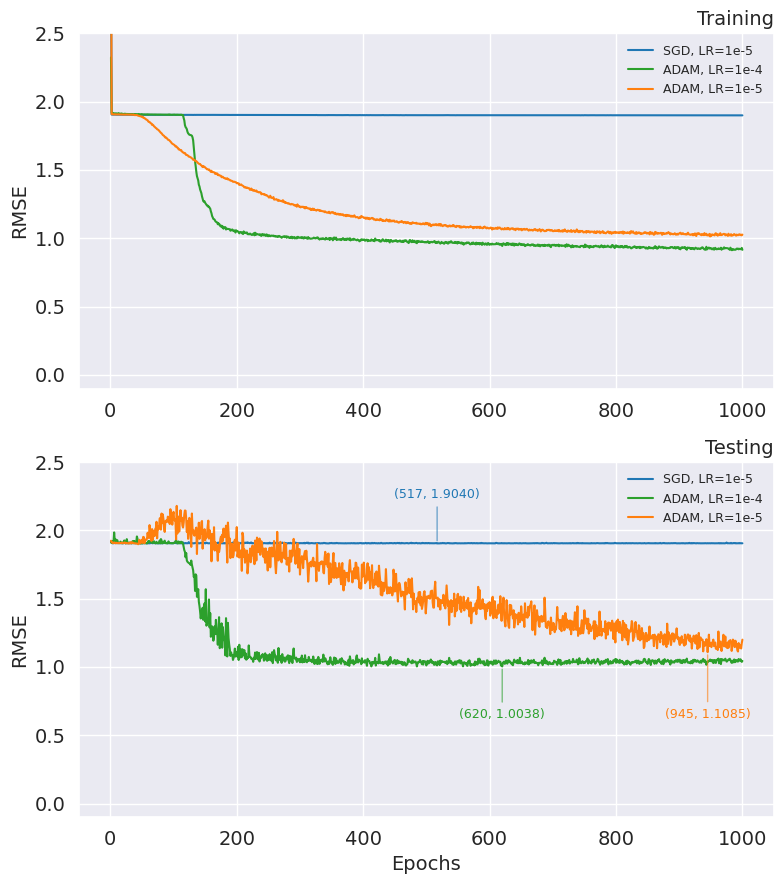

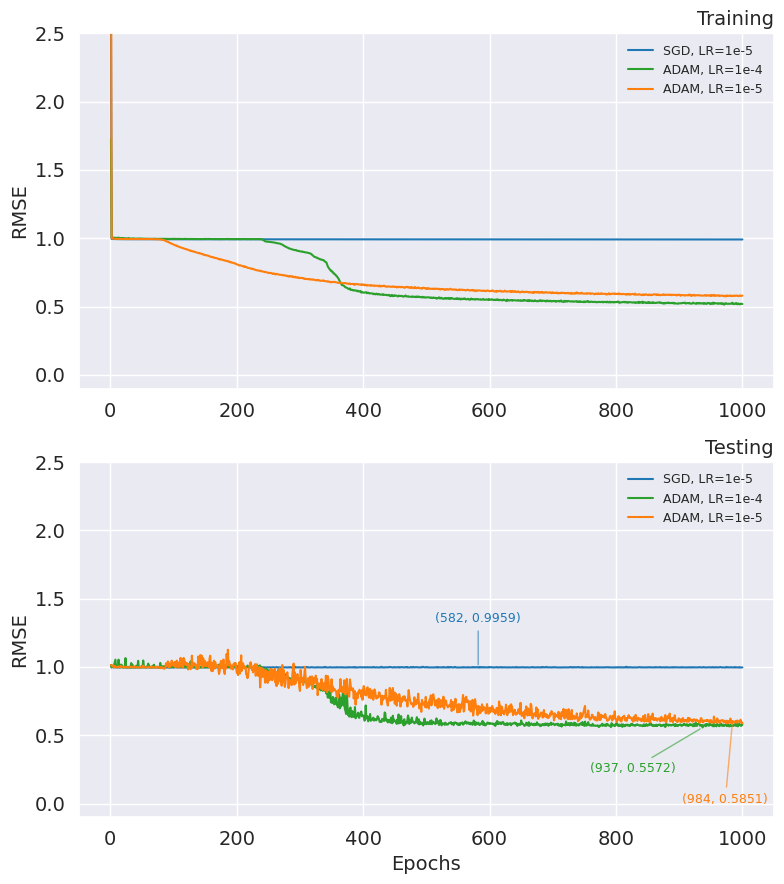

In [27]:
b_sgd_lr_1e_neg_5 = "../../results/run_results/bert_blstm/sgd.lr1e-5.bert_blstm-DMS_OLD-binding-2024-11-15_18-14/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_4 = "../../results/run_results/bert_blstm/adam.lr1e-4.bert_blstm-DMS_OLD-binding-2024-11-23_21-43/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/bert_blstm/adam.lr1e-5.bert_blstm-DMS_OLD-binding-2024-11-06_18-01/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/bert_blstm.binding"
b_coords = {
    "SGD, LR:1e-5": (0, 40),
    "ADAM, LR:1e-4": (0, -30),
    "ADAM, LR:1e-5": (0,-40)
}
print("Binding:")
plot_comparative_lr_blstm_log_file(b_sgd_lr_1e_neg_5, b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, b_coords, f"{comparison_file}.model_comp.pdf")

e_sgd_lr_1e_neg_5 = "../../results/run_results/bert_blstm/sgd.lr1e-5.bert_blstm-DMS_OLD-expression-2024-11-15_18-15/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/bert_blstm/adam.lr1e-4.bert_blstm-DMS_OLD-expression-2024-11-23_21-41/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/bert_blstm/adam.lr1e-5.bert_blstm-DMS_OLD-expression-2024-11-06_18-01/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/bert_blstm.expression"
e_coords = {
    "SGD, LR:1e-5": (0, 40),
    "ADAM, LR:1e-4": (-50, -25),
    "ADAM, LR:1e-5": (-5,-50)
}
print("\nExpression:")
plot_comparative_lr_blstm_log_file(e_sgd_lr_1e_neg_5,e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, e_coords, f"{comparison_file}.model_comp.pdf")

--- 
### ESM-FCN

Binding:
Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 54, rmse 0.5699
ADAM, LR=1e-4: epoch 90, rmse 0.5313
ADAM, LR=1e-5: epoch 400, rmse 0.5235

Expression:
Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 69, rmse 0.3438
ADAM, LR=1e-4: epoch 159, rmse 0.3163
ADAM, LR=1e-5: epoch 998, rmse 0.3171


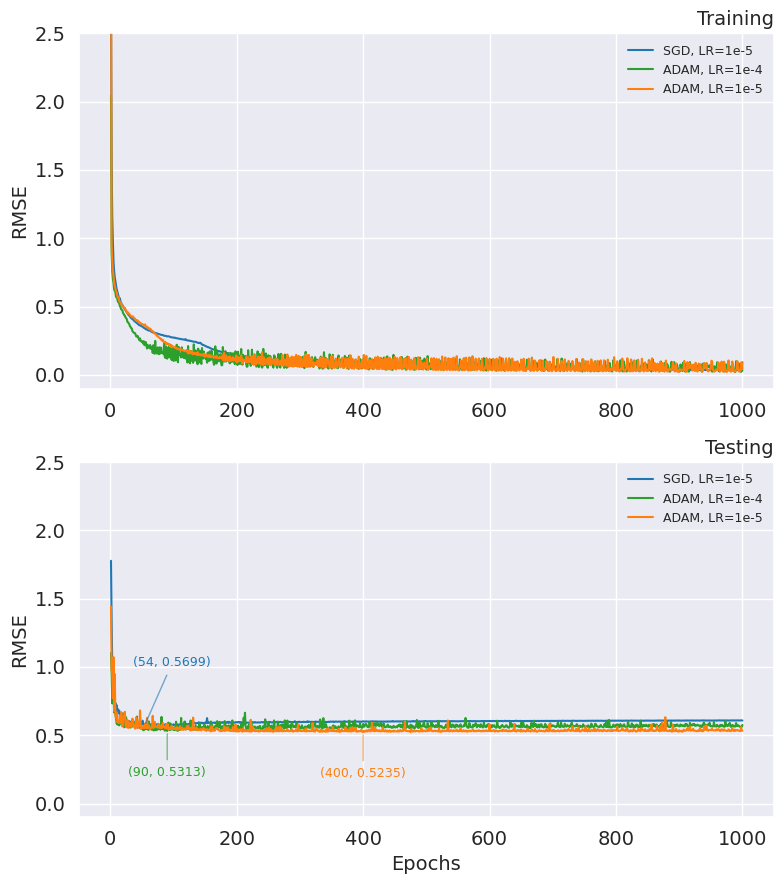

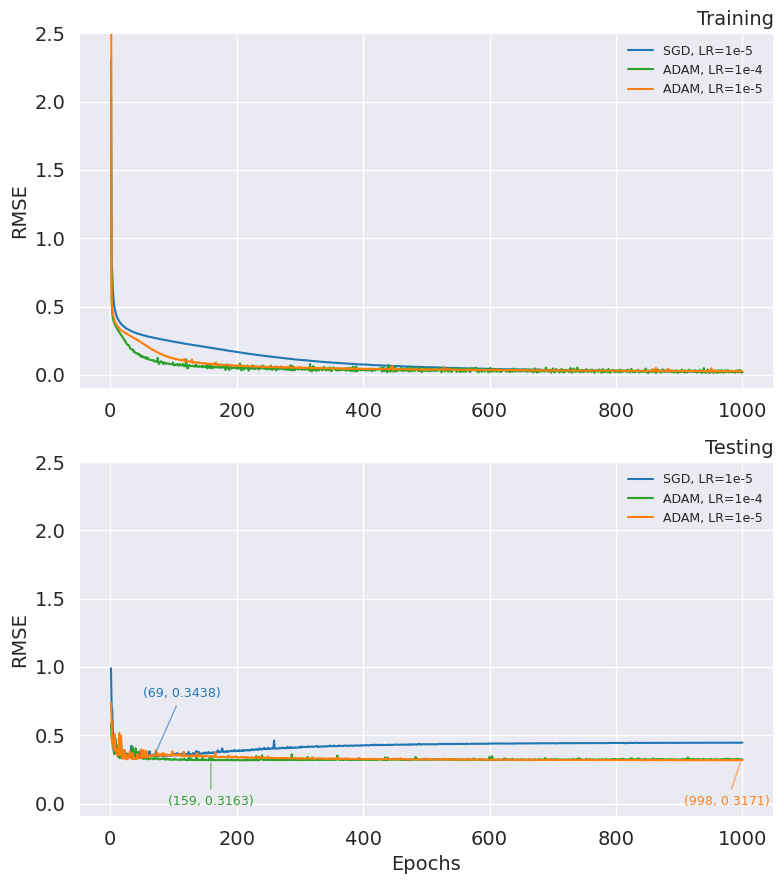

In [28]:
b_sgd_lr_1e_neg_5 = "../../results/run_results/esm_fcn/sgd.lr1e-5.esm_fcn-DMS_OLD-binding-2024-11-22_07-39/esm_fcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_4 = "../../results/run_results/esm_fcn/adam.lr1e-4.esm_fcn-DMS_OLD-binding-2024-11-24_05-48/esm_fcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_fcn/adam.lr1e-5.esm_fcn-DMS_OLD-binding-2024-11-23_20-45/esm_fcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_fcn.binding"
b_coords = {
    "SGD, LR:1e-5": (20, 50),
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (0,-25)
}
print("Binding:")
plot_comparative_lr_log_file(b_sgd_lr_1e_neg_5, b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, b_coords, f"{comparison_file}.model_comp.pdf")

e_sgd_lr_1e_neg_5 = "../../results/run_results/esm_fcn/sgd.lr1e-5.esm_fcn-DMS_OLD-expression-2024-11-22_07-40/esm_fcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/esm_fcn/adam.lr1e-4.esm_fcn-DMS_OLD-expression-2024-11-24_05-47/esm_fcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_fcn/adam.lr1e-5.esm_fcn-DMS_OLD-expression-2024-11-23_21-22/esm_fcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_fcn.expression"
e_coords = {
    "SGD, LR:1e-5": (20, 50),
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (-10,-25)
}
print("\nExpression:")
plot_comparative_lr_log_file(e_sgd_lr_1e_neg_5,e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, e_coords, f"{comparison_file}.model_comp.pdf")

---
### ESM-GCN

Binding:
Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 66, rmse 0.5733
ADAM, LR=1e-4: epoch 58, rmse 0.5426
ADAM, LR=1e-5: epoch 351, rmse 0.5272

Expression:
Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 60, rmse 0.3417
ADAM, LR=1e-4: epoch 171, rmse 0.3270
ADAM, LR=1e-5: epoch 939, rmse 0.3236


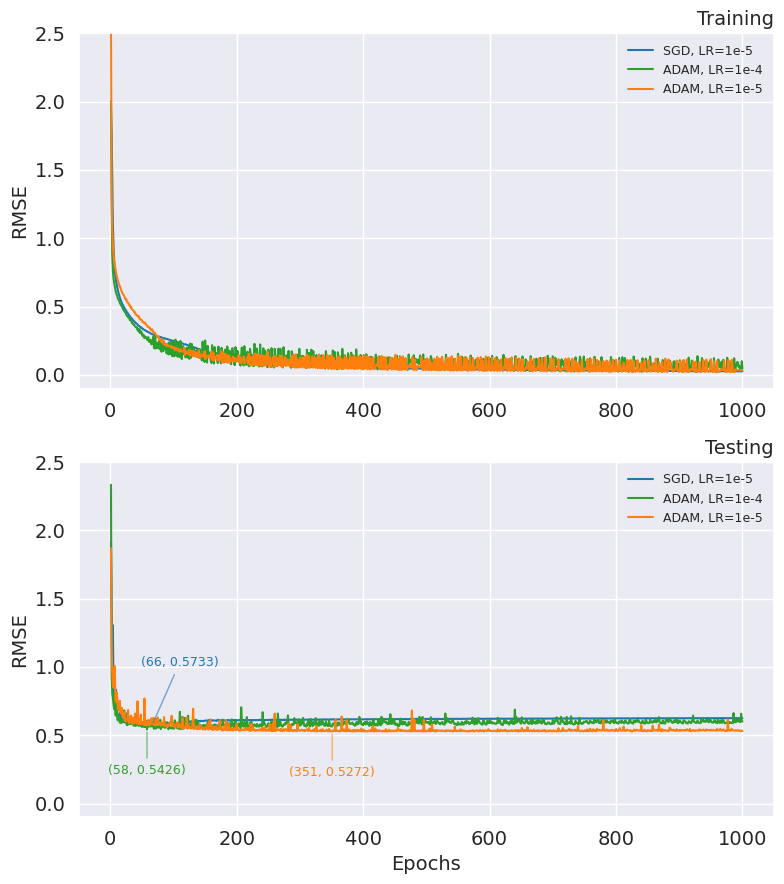

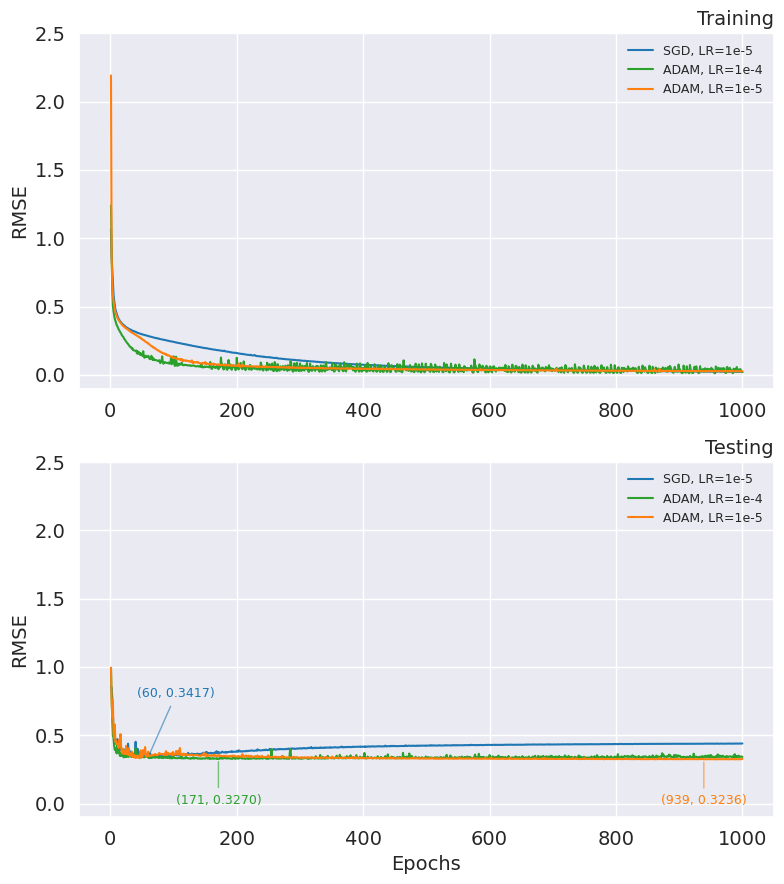

In [29]:
b_sgd_lr_1e_neg_5 = "../../results/run_results/esm_gcn/sgd.lr1e-5.esm-gcn-DMS_OLD-binding-2024-11-15_19-12/esm-gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_4 = "../../results/run_results/esm_gcn/adam.lr1e-4.esm_gcn-DMS_OLD-binding-2024-11-25_15-54/esm_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_gcn/adam.lr1e-5.esm_gcn-DMS_OLD-binding-2024-11-23_21-36/esm_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_gcn.binding"
b_coords = {
    "SGD, LR:1e-5": (20, 50),
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (0,-25)
}
print("Binding:")
plot_comparative_lr_log_file(b_sgd_lr_1e_neg_5, b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, b_coords, f"{comparison_file}.model_comp.pdf")

e_sgd_lr_1e_neg_5 = "../../results/run_results/esm_gcn/sgd.lr1e-5.esm-gcn-DMS_OLD-expression-2024-11-15_19-11/esm-gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/esm_gcn/adam.lr1e-4.esm_gcn-DMS_OLD-expression-2024-11-25_15-55/esm_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_gcn/adam.lr1e-5.esm_gcn-DMS_OLD-expression-2024-11-23_21-45/esm_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_gcn.expression"
e_coords = {
    "SGD, LR:1e-5": (20, 50),
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (0,-25)
}
print("\nExpression:")
plot_comparative_lr_log_file(e_sgd_lr_1e_neg_5,e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, e_coords, f"{comparison_file}.model_comp.pdf")

--- 
### ESM-BLSTM

Binding:
Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 69, rmse 0.5656
ADAM, LR=1e-4: epoch 139, rmse 0.5452
ADAM, LR=1e-5: epoch 325, rmse 0.5230

Expression:
Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 72, rmse 0.3391
ADAM, LR=1e-4: epoch 300, rmse 0.3187
ADAM, LR=1e-5: epoch 921, rmse 0.3216


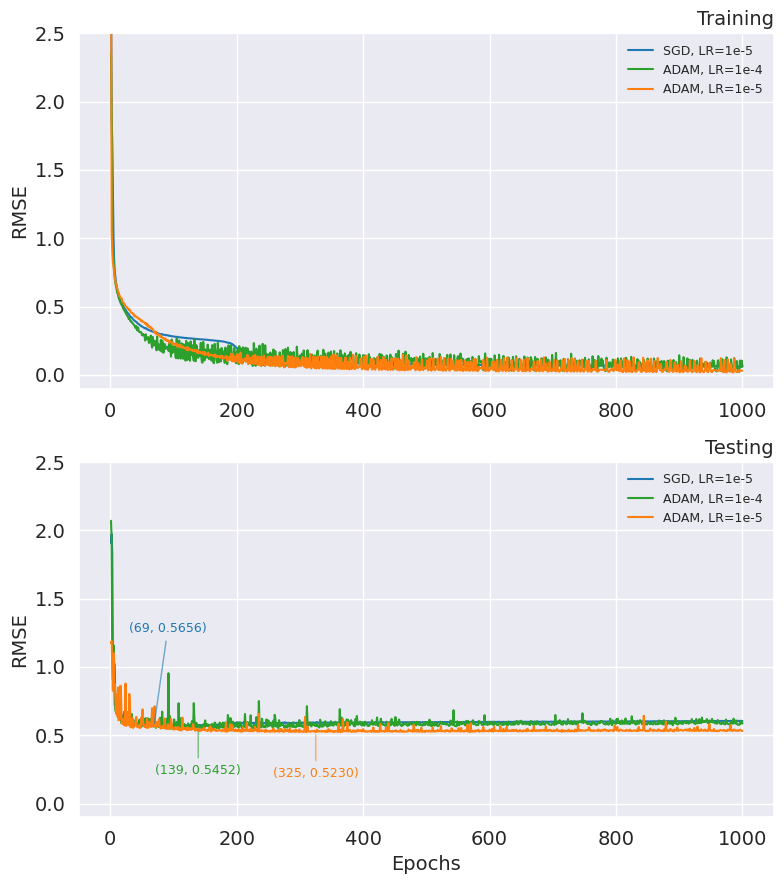

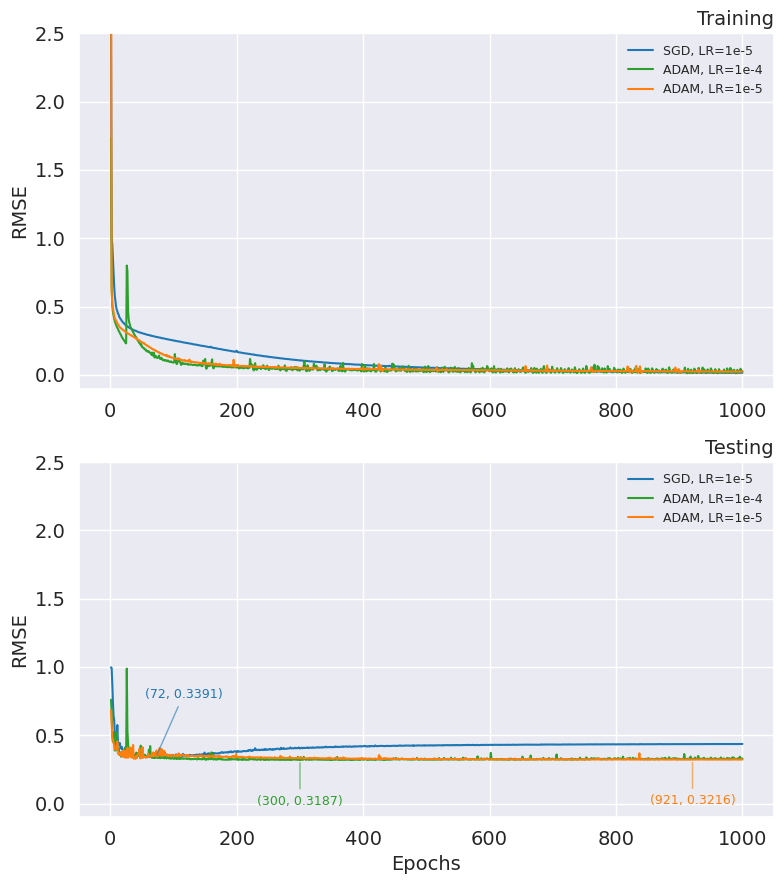

In [30]:
b_sgd_lr_1e_neg_5 = "../../results/run_results/esm_blstm/sgd.lr1e-5.esm_blstm-DMS_OLD-binding-2024-11-23_21-54/esm_blstm-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_4 = "../../results/run_results/esm_blstm/adam.lr1e-4.esm_blstm-DMS_OLD-binding-2024-11-26_08-29/esm_blstm-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_blstm/adam.lr1e-5.esm_blstm-DMS_OLD-binding-2024-11-23_22-05/esm_blstm-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_blstm.binding"
b_coords = {
    "SGD, LR:1e-5": (10, 75),
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (0,-25)
}
print("Binding:")
plot_comparative_lr_log_file(b_sgd_lr_1e_neg_5, b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, b_coords, f"{comparison_file}.model_comp.pdf")

e_sgd_lr_1e_neg_5 = "../../results/run_results/esm_blstm/sgd.lr1e-5.esm_blstm-DMS_OLD-expression-2024-10-22_14-39/esm_blstm-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/esm_blstm/adam.lr1e-4.esm_blstm-DMS_OLD-expression-2024-11-26_08-28/esm_blstm-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_blstm/adam.lr1e-5.esm_blstm-DMS_OLD-expression-2024-11-26_01-54/esm_blstm-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_blstm.expression"
e_coords = {
    "SGD, LR:1e-5": (20, 50),
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (0,-25)
}
print("\nExpression:")
plot_comparative_lr_log_file(e_sgd_lr_1e_neg_5,e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, e_coords, f"{comparison_file}.model_comp.pdf")

---
### ESM-BLSTM Initialized w/ BERT_MLM_ESM_INIT

Binding:
Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 132, rmse 0.6314
ADAM, LR=1e-4: epoch 58, rmse 0.5883
ADAM, LR=1e-5: epoch 333, rmse 0.5762

Expression:
Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 120, rmse 0.3771
ADAM, LR=1e-4: epoch 61, rmse 0.3789
ADAM, LR=1e-5: epoch 984, rmse 0.3461


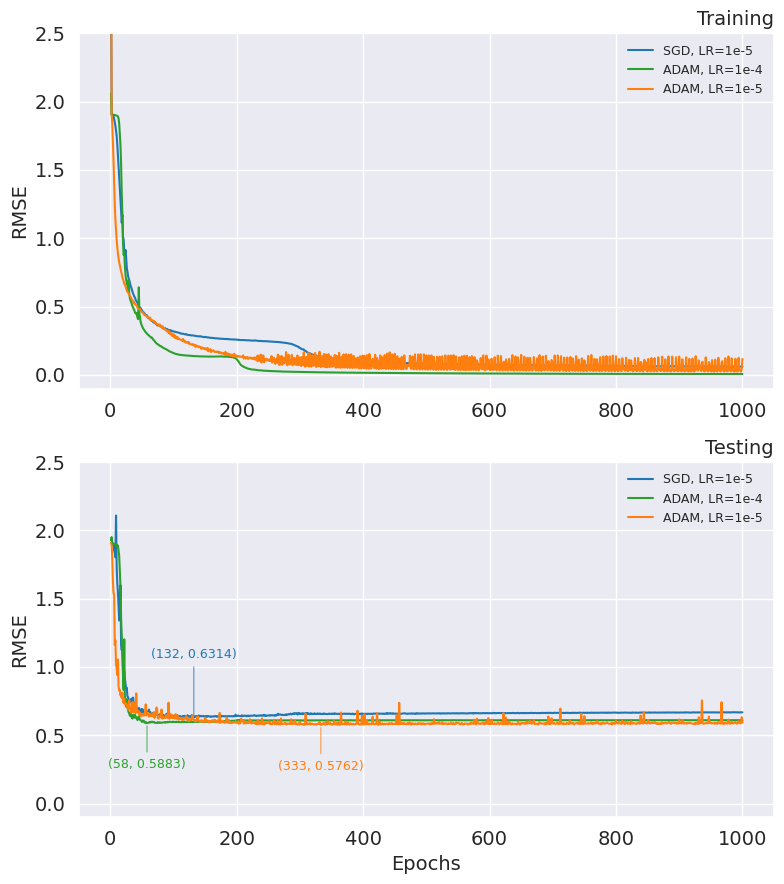

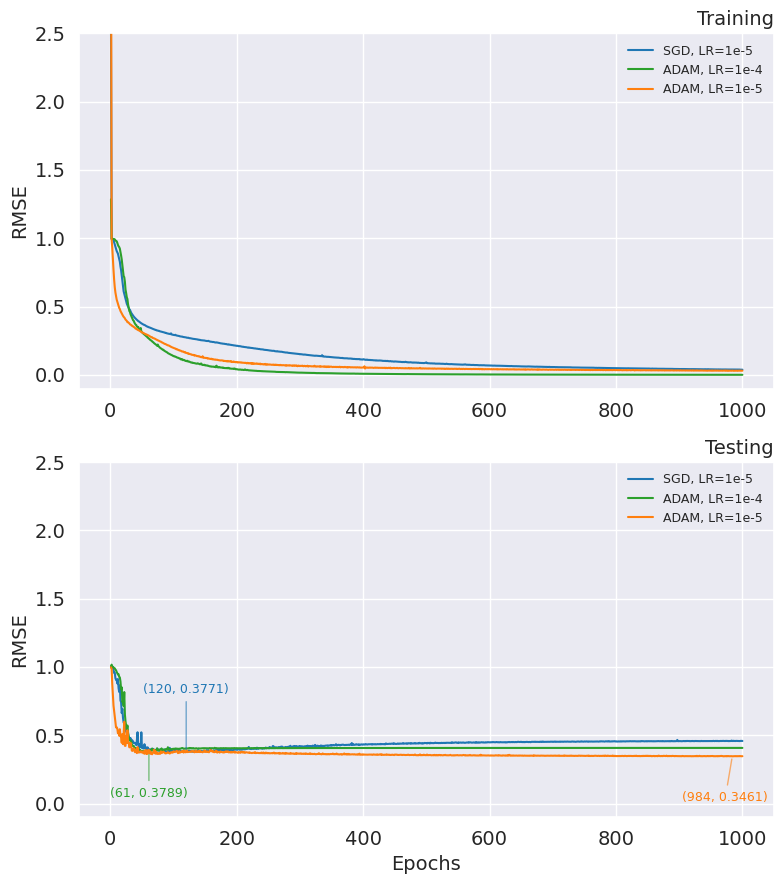

In [31]:
b_sgd_lr_1e_neg_5 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/re.sgd.lr1e-5.esm_blstm-bert_mlm_esm_init-DMS_OLD-binding-2024-11-27_16-57/esm_blstm-bert_mlm_esm_init-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_4 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-4.esm_blstm-bert_mlm_esm_init-DMS_OLD-binding-2024-11-21_10-38/esm_blstm-bert_mlm_esm_init-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/re.adam.lr1e-5.esm_blstm-bert_mlm_esm_init-DMS_OLD-binding-2024-11-27_16-59/esm_blstm-bert_mlm_esm_init-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_blstm-bert_mlm_esm_init.binding"
b_coords = {
    "SGD, LR:1e-5": (0, 50),
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (0,-25)
}
print("Binding:")
plot_comparative_lr_log_file(b_sgd_lr_1e_neg_5, b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, b_coords, f"{comparison_file}.model_comp.pdf")

e_sgd_lr_1e_neg_5 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/re.sgd.lr1e-5.esm_blstm-bert_mlm_esm_init-DMS_OLD-expression-2024-11-27_16-57/esm_blstm-bert_mlm_esm_init-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-4.esm_blstm-bert_mlm_esm_init-DMS_OLD-expression-2024-11-21_10-38/esm_blstm-bert_mlm_esm_init-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/re.adam.lr1e-5.esm_blstm-bert_mlm_esm_init-DMS_OLD-expression-2024-11-27_16-58/esm_blstm-bert_mlm_esm_init-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_blstm-bert_mlm_esm_init.expression"
e_coords = {
    "SGD, LR:1e-5": (0, 50),
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (-5,-25)
}
print("\nExpression:")
plot_comparative_lr_log_file(e_sgd_lr_1e_neg_5,e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, e_coords, f"{comparison_file}.model_comp.pdf")

---
### FCN ESM-CLS Preembedded

Binding:
Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 976, rmse 1.2884
ADAM, LR=1e-4: epoch 272, rmse 1.2802
ADAM, LR=1e-5: epoch 929, rmse 1.2137

Expression:
Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 973, rmse 0.6697
ADAM, LR=1e-4: epoch 460, rmse 0.6579
ADAM, LR=1e-5: epoch 991, rmse 0.6180


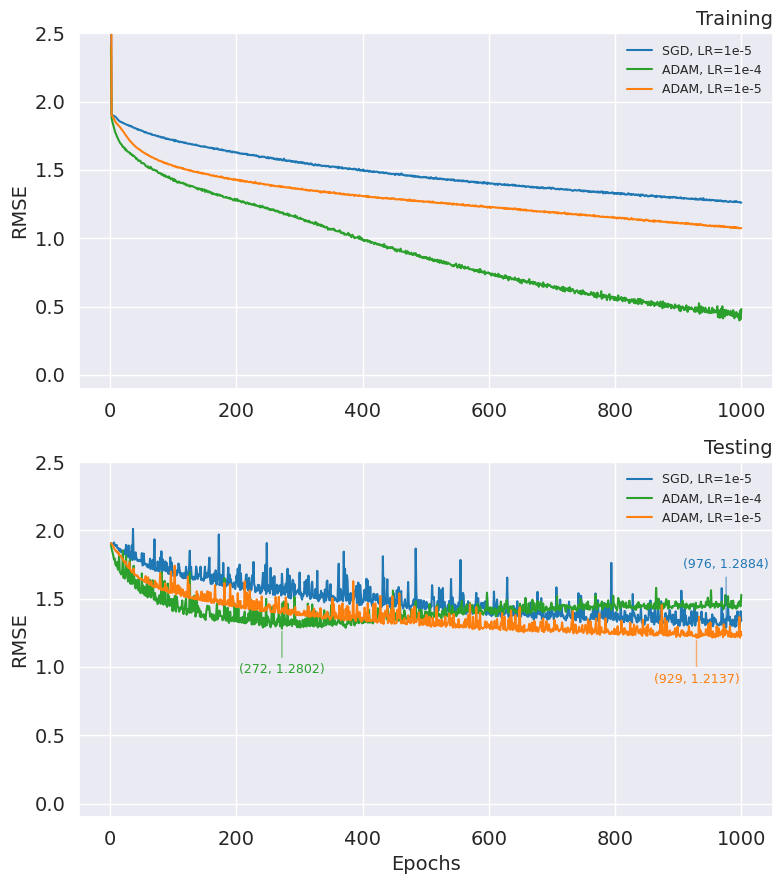

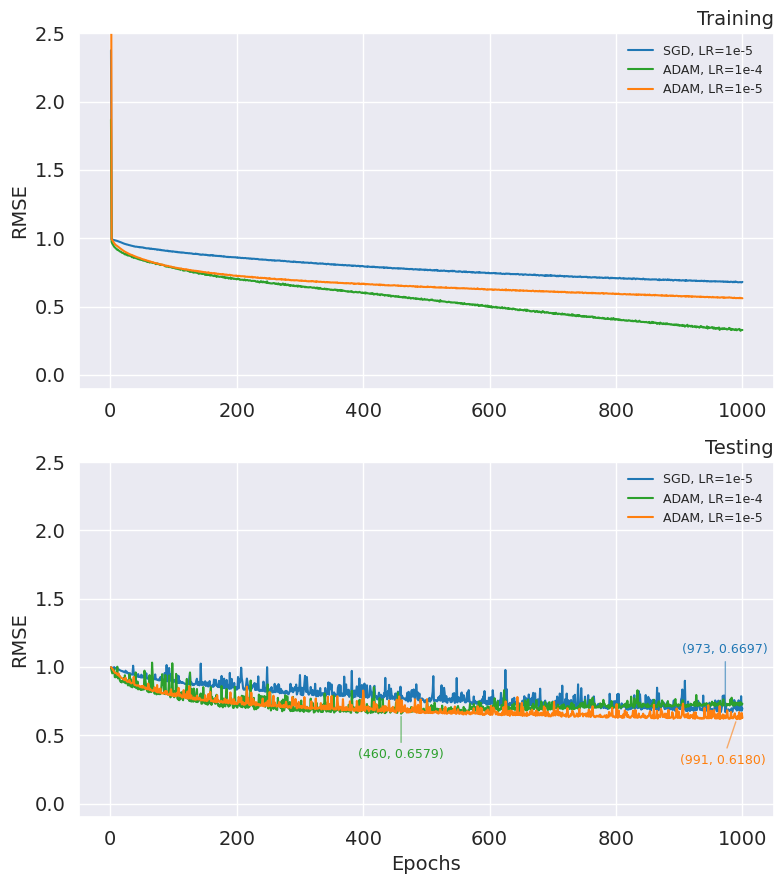

In [32]:
b_sgd_lr_1e_neg_5 = "../../results/run_results/fcn-ESM_CLS_preembedded/sgd.lr1e-5.fcn-ESM_CLS_preembedded-DMS_OLD-binding-2024-11-14_02-07/fcn-ESM_CLS_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_4 = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-4.fcn-ESM_CLS_preembedded-DMS_OLD-binding-2024-11-21_10-22/fcn-ESM_CLS_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-5.fcn-ESM_CLS_preembedded-DMS_OLD-binding-2024-11-15_17-49/fcn-ESM_CLS_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/fcn-esm_cls_preembedded.binding"
b_coords = {
    "SGD, LR:1e-5": (0, 50),
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (0,-25)
}
print("Binding:")
plot_comparative_lr_log_file(b_sgd_lr_1e_neg_5, b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, b_coords, f"{comparison_file}.model_comp.pdf")

e_sgd_lr_1e_neg_5 = "../../results/run_results/fcn-ESM_CLS_preembedded/sgd.lr1e-5.fcn-ESM_CLS_preembedded-DMS_OLD-expression-2024-11-14_02-06/fcn-ESM_CLS_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-4.fcn-ESM_CLS_preembedded-DMS_OLD-expression-2024-11-21_10-23/fcn-ESM_CLS_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-5.fcn-ESM_CLS_preembedded-DMS_OLD-expression-2024-11-15_17-58/fcn-ESM_CLS_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/fcn-esm_cls_preembedded.expression"
e_coords = {
    "SGD, LR:1e-5": (0, 50),
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (-10,-25)
}
print("\nExpression:")
plot_comparative_lr_log_file(e_sgd_lr_1e_neg_5,e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, e_coords, f"{comparison_file}.model_comp.pdf")

---
### BLSTM ESM-AA Preembedded

Binding:
Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 980, rmse 0.6044
ADAM, LR=1e-4: epoch 255, rmse 0.5519
ADAM, LR=1e-5: epoch 864, rmse 0.5988

Expression:
Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 995, rmse 0.4138
ADAM, LR=1e-4: epoch 194, rmse 0.3262
ADAM, LR=1e-5: epoch 952, rmse 0.3603


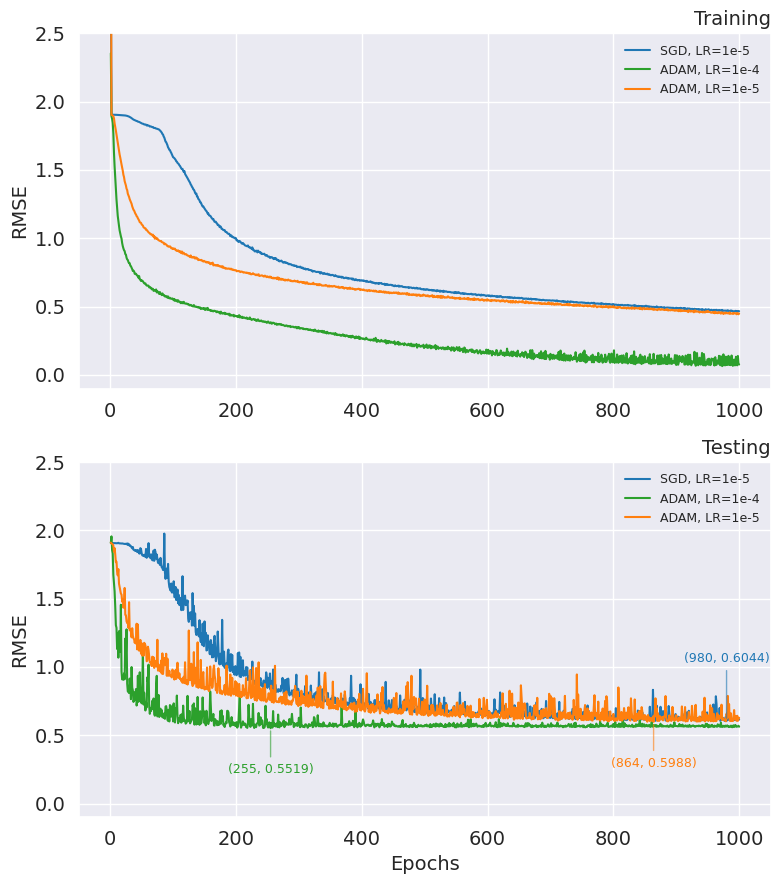

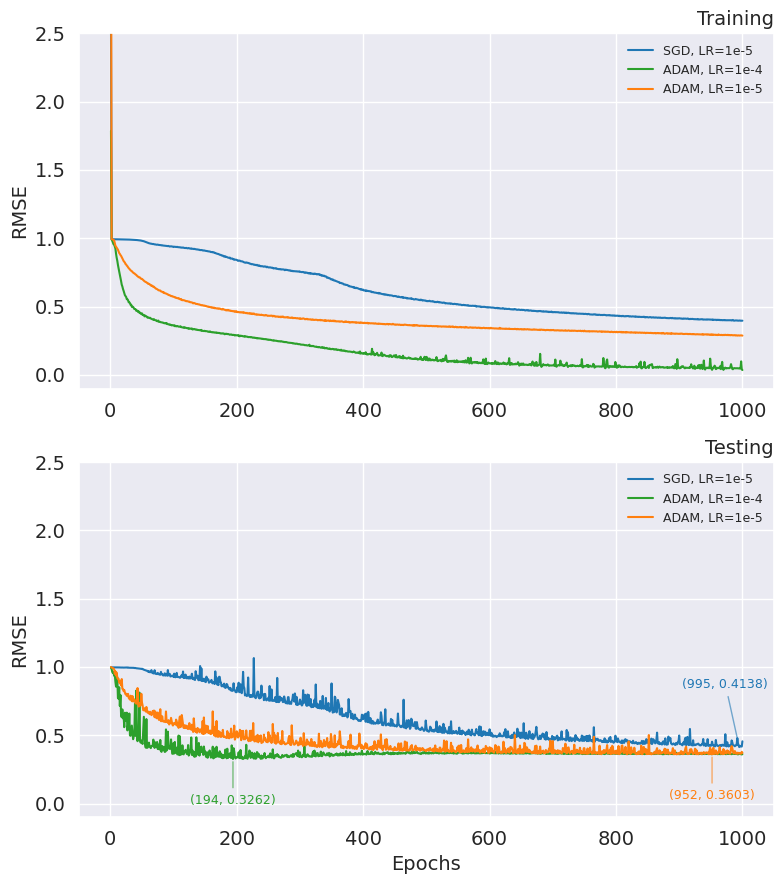

In [33]:
b_sgd_lr_1e_neg_5 = "../../results/run_results/blstm-ESM_AA_preembedded/sgd.lr1e-5.blstm-ESM_AA_preembedded-DMS_OLD-binding-2024-11-12_21-02/blstm-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_4 = "../../results/run_results/blstm-ESM_AA_preembedded/re.adam.lr1e-4.blstm-ESM_AA_preembedded-DMS_OLD-binding-2024-11-29_20-44/blstm-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/blstm-ESM_AA_preembedded/re.adam.lr1e-5.blstm-ESM_AA_preembedded-DMS_OLD-binding-2024-11-29_20-40/blstm-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/blstm-esm_aa_preembedded.binding"
b_coords = {
    "SGD, LR:1e-5": (0, 50),
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (0,-25)
}
print("Binding:")
plot_comparative_lr_log_file(b_sgd_lr_1e_neg_5, b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, b_coords, f"{comparison_file}.model_comp.pdf")

e_sgd_lr_1e_neg_5 = "../../results/run_results/blstm-ESM_AA_preembedded/sgd.lr1e-5.blstm-ESM_AA_preembedded-DMS_OLD-expression-2024-11-12_20-57/blstm-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/blstm-ESM_AA_preembedded/re.adam.lr1e-4.blstm-ESM_AA_preembedded-DMS_OLD-expression-2024-11-29_20-43/blstm-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/blstm-ESM_AA_preembedded/re.adam.lr1e-5.blstm-ESM_AA_preembedded-DMS_OLD-expression-2024-11-29_20-41/blstm-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/blstm-esm_aa_preembedded.expression"
e_coords = {
    "SGD, LR:1e-5": (-10, 50),
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (0,-25)
}
print("\nExpression:")
plot_comparative_lr_log_file(e_sgd_lr_1e_neg_5,e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, e_coords, f"{comparison_file}.model_comp.pdf")

---
### BLSTM NLP Preembedded w/ Finetuned BERT_MLM_ESM_INIT

Binding:
Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 992, rmse 1.9044
ADAM, LR=1e-4: epoch 897, rmse 1.9049
ADAM, LR=1e-5: epoch 983, rmse 0.8833

Expression:
Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 978, rmse 0.9960
ADAM, LR=1e-4: epoch 193, rmse 0.9962
ADAM, LR=1e-5: epoch 1000, rmse 0.5418


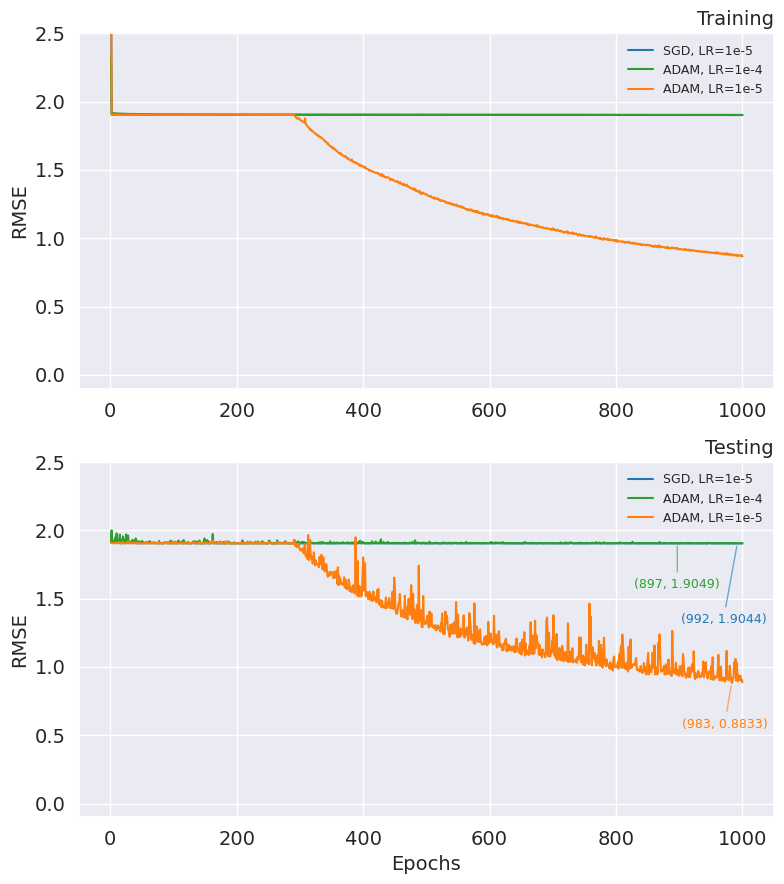

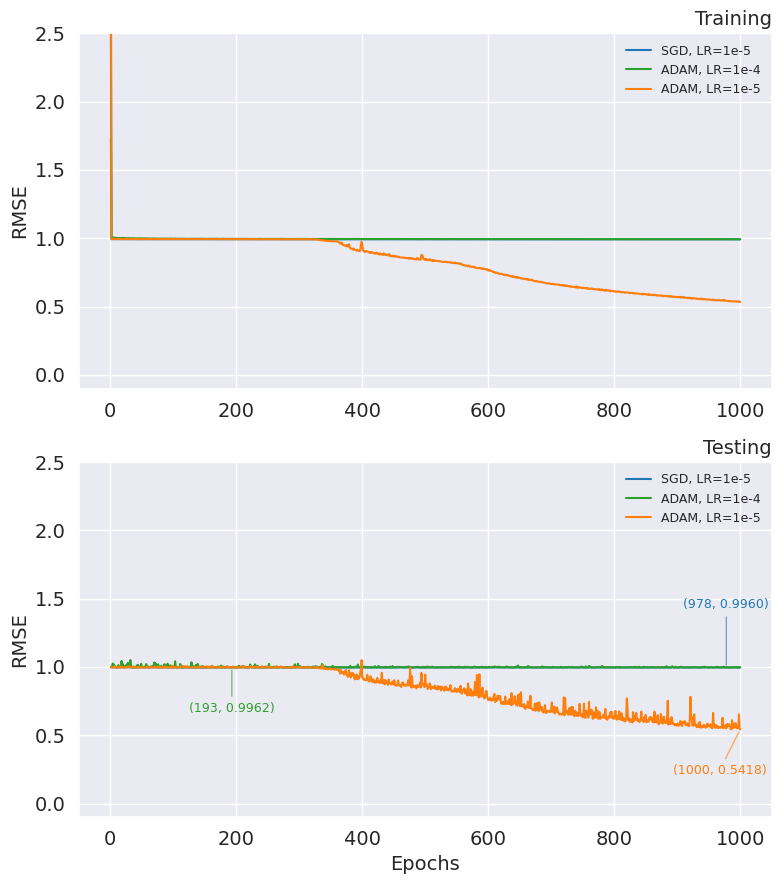

In [34]:
b_sgd_lr_1e_neg_5 = "../../results/run_results/blstm-NLP_preembedded/sgd.lr1e-5.blstm-NLP_preembedded-DMS_OLD-binding-2024-11-13_12-00/blstm-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_4 = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-4.blstm-NLP_preembedded-DMS_OLD-binding-2024-11-23_21-09/blstm-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-5.blstm-NLP_preembedded-DMS_OLD-binding-2024-11-15_23-16/blstm-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/blstm-nlp_preembedded.binding"
b_coords = {
    "SGD, LR:1e-5": (-10, -50),
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (-5,-25)
}
print("Binding:")
plot_comparative_lr_log_file(b_sgd_lr_1e_neg_5, b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, b_coords, f"{comparison_file}.model_comp.pdf")

e_sgd_lr_1e_neg_5 = "../../results/run_results/blstm-NLP_preembedded/sgd.lr1e-5.blstm-NLP_preembedded-DMS_OLD-expression-2024-11-13_12-00/blstm-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-4.blstm-NLP_preembedded-DMS_OLD-expression-2024-11-23_20-54/blstm-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-5.blstm-NLP_preembedded-DMS_OLD-expression-2024-11-15_23-17/blstm-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/blstm-nlp_preembedded.expression"
e_coords = {
    "SGD, LR:1e-5": (0, 50),
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (-15,-25)
}
print("\nExpression:")
plot_comparative_lr_log_file(e_sgd_lr_1e_neg_5,e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, e_coords, f"{comparison_file}.model_comp.pdf")

---
### GCN ESM-AA Preembedded

Binding:
Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 988, rmse 1.3791
ADAM, LR=1e-4: epoch 988, rmse 1.0580
ADAM, LR=1e-5: epoch 994, rmse 1.2941

Expression:
Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 997, rmse 0.8043
ADAM, LR=1e-4: epoch 998, rmse 0.5431
ADAM, LR=1e-5: epoch 992, rmse 0.6819


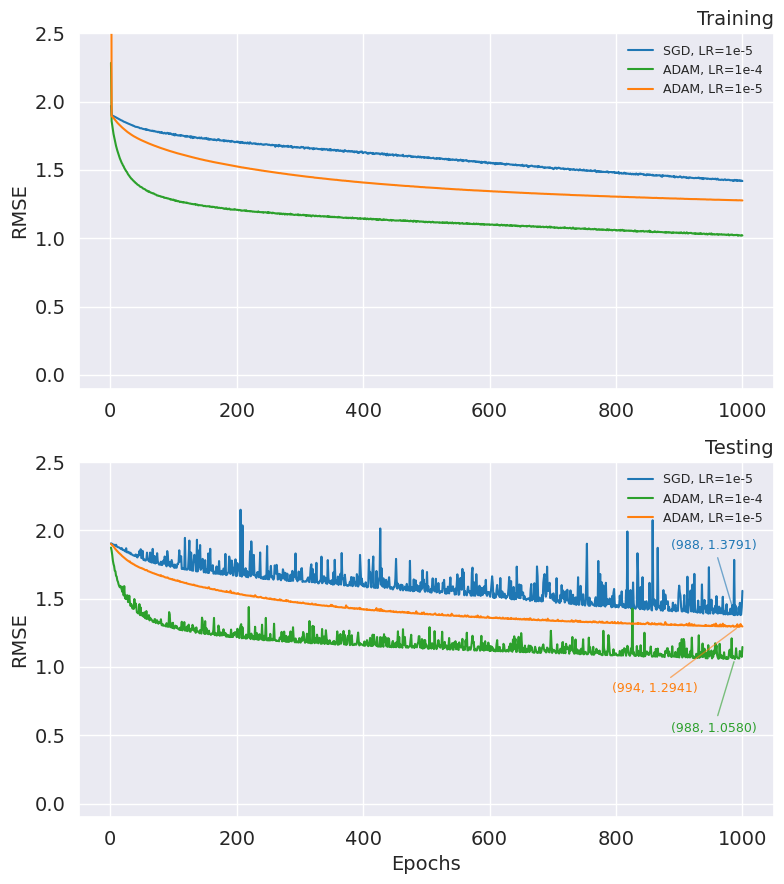

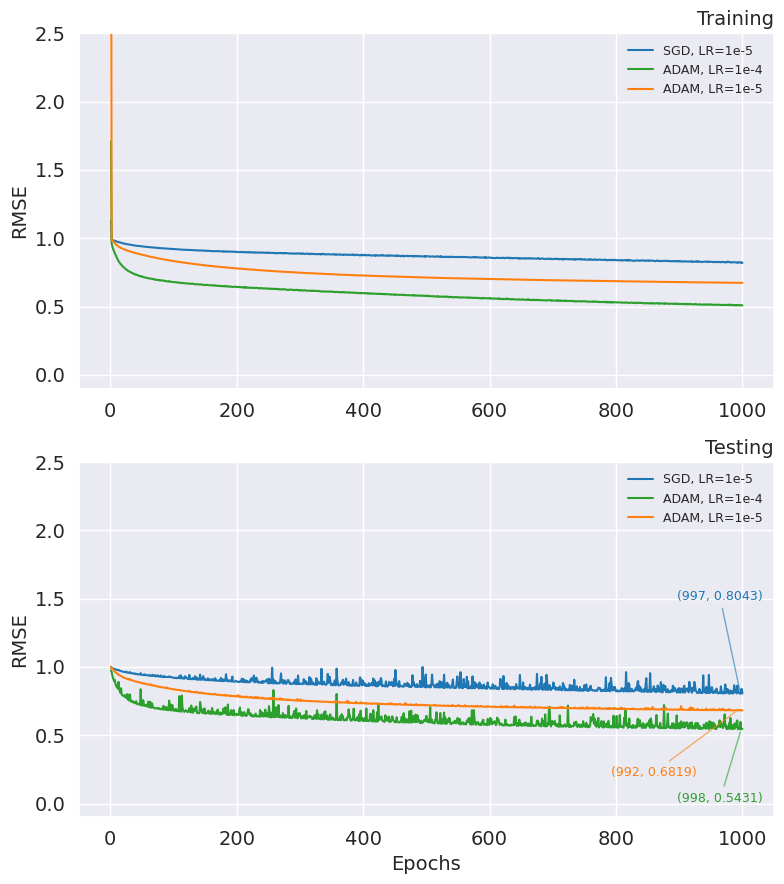

In [35]:
b_sgd_lr_1e_neg_5 = "../../results/run_results/gcn-ESM_AA_preembedded/sgd.lr1e-5.gcn-ESM_AA_preembedded-DMS_OLD-binding-2024-11-16_20-26/gcn-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_4 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-4.gcn-ESM_AA_preembedded-DMS_OLD-binding-2024-11-21_17-07/gcn-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-5.gcn-ESM_AA_preembedded-DMS_OLD-binding-2024-11-21_17-06/gcn-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/gcn-esm_aa_preembedded.binding"
b_coords = {
    "SGD, LR:1e-5": (-15, 55),
    "ADAM, LR:1e-4": (-15,-45),
    "ADAM, LR:1e-5": (-60,-40)
}
print("Binding:")
plot_comparative_lr_log_file(b_sgd_lr_1e_neg_5, b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, b_coords, f"{comparison_file}.model_comp.pdf")

e_sgd_lr_1e_neg_5 = "../../results/run_results/gcn-ESM_AA_preembedded/sgd.lr1e-5.gcn-ESM_AA_preembedded-DMS_OLD-expression-2024-11-16_20-27/gcn-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-4.gcn-ESM_AA_preembedded-DMS_OLD-expression-2024-11-21_17-08/gcn-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-5.gcn-ESM_AA_preembedded-DMS_OLD-expression-2024-11-16_20-10/gcn-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/gcn-esm_aa_preembedded.expression"
e_coords = {
    "SGD, LR:1e-5": (-15, 75),
    "ADAM, LR:1e-4": (-15,-45),
    "ADAM, LR:1e-5": (-60,-40)
}
print("\nExpression:")
plot_comparative_lr_log_file(e_sgd_lr_1e_neg_5,e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, e_coords, f"{comparison_file}.model_comp.pdf")